In [3]:
import osmnx as ox

In [1]:
import geopandas as gpd

In [2]:
kootenai = gpd.read_file("../data/processed/kootenai_tracts.gpkg")

In [4]:
kootenai.head()

,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,16,055,001901,1400000US16055001901,16055001901,19.01,Census Tract 19.01,ID,Kootenai County,Idaho,CT,1136651855,20841605,"POLYGON ((518804.812 5256267.794, 518869.358 5..."
1,16,055,000902,1400000US16055000902,16055000902,9.02,Census Tract 9.02,ID,Kootenai County,Idaho,CT,2875540,105404,"POLYGON ((513681.538 5282909.432, 513851.67 52..."
2,16,055,001300,1400000US16055001300,16055001300,13,Census Tract 13,ID,Kootenai County,Idaho,CT,2587963,0,"POLYGON ((516034.839 5282786.303, 516035.658 5..."
3,16,055,000703,1400000US16055000703,16055000703,7.03,Census Tract 7.03,ID,Kootenai County,Idaho,CT,4486245,0,"POLYGON ((512764.547 5286117.091, 512764.091 5..."
4,16,055,000800,1400000US16055000800,16055000800,8,Census Tract 8,ID,Kootenai County,Idaho,CT,8955722,484816,"POLYGON ((511155.293 5285123.734, 511156.991 5..."


<Axes: >

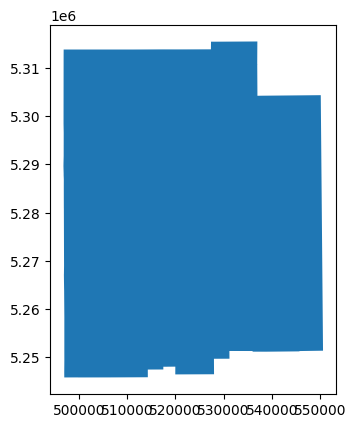

In [7]:
county_boundary = kootenai.dissolve()
county_boundary.plot()

In [9]:
tags = {"shop": ["supermarket", "grocery"]}

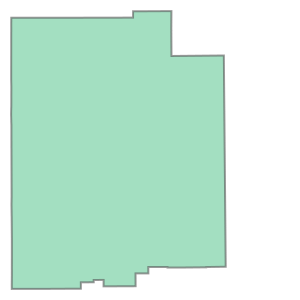

In [11]:
county_boundary.geometry.iloc[0]

In [12]:
county_boundary = county_boundary.to_crs(4326)

In [13]:
stores = ox.features_from_polygon(
    county_boundary.geometry.iloc[0],
    tags
)

In [14]:
stores.head()

geometry      addr:city  \
element id                                                        
node    6960758897   POINT (-116.79343 47.70574)            NaN   
        8923594212   POINT (-116.70236 47.94815)          Athol   
        11055182898  POINT (-116.79152 47.73515)  Coeur d'Alene   
        11066194802   POINT (-116.7877 47.75288)         Hayden   
        11068205595  POINT (-116.78903 47.74616)         Hayden   

                    addr:housenumber addr:postcode           addr:street  \
element id                                                                 
node    6960758897               NaN           NaN                   NaN   
        8923594212              6101           NaN       East Highway 54   
        11055182898              315    83815-7750  West Canfield Avenue   
        11066194802               88         83835   West Commerce Drive   
        11068205595              161         83835   West Prairie Avenue   

                                         name  \
element id                                      
node    6960758897             Grocery Outlet   
        8923594212         Little Town Market   
        11055182898                    Target   
        11066194802  Flour Mill Natural Foods   
        11068205595                Albertsons   

                                                         opening_hours  \
element id                                                               
node    6960758897                                   Mo-Su 08:00-21:00   
        8923594212                                                 NaN   
        11055182898                                        08:00-23:00   
        11066194802                   Mo-Fr 09:00-17:30, Sa 9:00-15:00   
        11068205595  Mo-Fr 06:00-23:00; Sa 06:00-23:00; Su 06:00-23:00   

                            shop           brand brand:wikidata  ...  \
element id                                                       ...   
node    6960758897   supermarket  Grocery Outlet       Q5609934  ...   
        8923594212   supermarket             NaN            NaN  ...   
        11055182898  supermarket          Target       Q1046951  ...   
        11066194802  supermarket             NaN            NaN  ...   
        11068205595  supermarket      Albertsons       Q2831861  ...   

                    toilets:wheelchair wheelchair building:levels  \
element id                                                          
node    6960758897                 NaN        NaN             NaN   
        8923594212                 NaN        NaN             NaN   
        11055182898                NaN        NaN             NaN   
        11066194802                NaN        NaN             NaN   
        11068205595                NaN        NaN             NaN   

                    not:brand:wikidata payment:cash payment:cheque  \
element id                                                           
node    6960758897                 NaN          NaN            NaN   
        8923594212                 NaN          NaN            NaN   
        11055182898                NaN          NaN            NaN   
        11066194802                NaN          NaN            NaN   
        11068205595                NaN          NaN            NaN   

                    payment:contactless payment:credit_cards  \
element id                                                     
node    6960758897                  NaN                  NaN   
        8923594212                  NaN                  NaN   
        11055182898                 NaN                  NaN   
        11066194802                 NaN                  NaN   
        11068205595                 NaN                  NaN   

                    payment:debit_cards payment:ebt  
element id                                           
node    6960758897                  NaN         NaN  
        8923594212                  NaN         NaN  
        11055182898          

In [15]:
stores.shape

(32, 46)

In [16]:
stores = stores[stores.geometry.type == "Point"]

<Axes: >

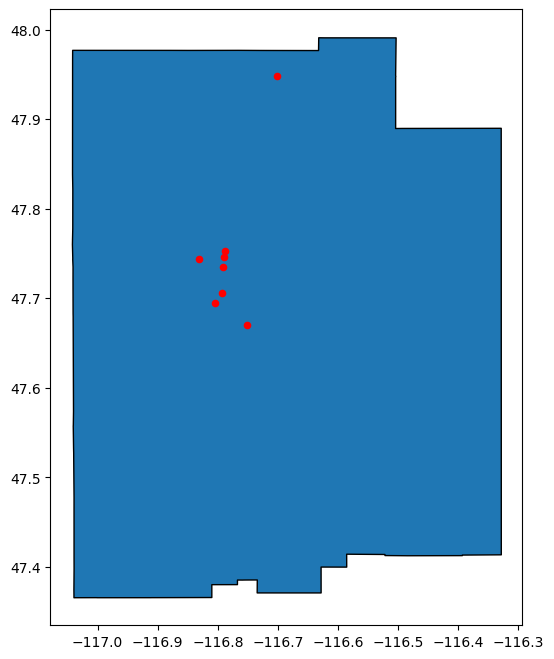

In [17]:
ax = county_boundary.plot(figsize=(8,8), edgecolor="black")

stores.plot(
    ax=ax,
    color="red",
    markersize=20
)